# 07 — Evaluación incremental de parámetros ECG

Este notebook consolida las métricas generadas en `06_modelado_predictivo.ipynb` y evalúa el aporte incremental de las modalidades de información definidas en el TFM.

El foco principal es la comparación entre el escenario clínico basal y el escenario clínico enriquecido con parámetros electrocardiográficos estructurados:

```text
E1_CLINICO → E3_CLINICO_ECG
```

Como análisis complementario, se evalúa si el aporte ECG se mantiene cuando el escenario base ya incorpora antecedentes clínicos derivados mediante NLP:

```text
E2_CLINICO_NLP → E4_CLINICO_NLP_ECG
```

Este notebook no entrena modelos. Su función es comparar resultados ya obtenidos, generar tablas de diferencias absolutas y relativas, construir rankings de modelos y exportar artefactos de evaluación incremental.

## 1. Entradas y salidas

### Entradas esperadas

```text
Metricas_Modelado_TFM.xlsx
Predicciones_Modelos_TFM.xlsx
Variables_Modelado_TFM.xlsx
```

### Salidas generadas

```text
Comparacion_Incremental_ECG_TFM.xlsx
Ranking_Modelos_Escenarios_TFM.xlsx
Resumen_Evaluacion_Incremental_TFM.txt
metricas_por_escenario_modelo.png
delta_incremental_ecg.png
ranking_auprc_por_escenario.png
```

In [12]:
# Instalación de dependencias requeridas
import importlib.util
import subprocess
import sys

DEPENDENCIAS = {
    "pandas": "pandas",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "xlsxwriter": "XlsxWriter",
    "matplotlib": "matplotlib",
}

for modulo, paquete in DEPENDENCIAS.items():
    if importlib.util.find_spec(modulo) is None:
        print(f"Instalando dependencia faltante: {paquete}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])
    else:
        print(f"Dependencia disponible: {modulo}")

Dependencia disponible: pandas
Dependencia disponible: numpy
Dependencia disponible: openpyxl
Dependencia disponible: xlsxwriter
Dependencia disponible: matplotlib


In [13]:
# Carga de librerías
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 2. Configuración de rutas

Por defecto, el notebook usa como directorio base la carpeta local donde se ejecuta. Si los archivos se encuentran en otra ubicación, modificar `BASE_DIR`.

In [ ]:
# Configuración de rutas
BASE_DIR = Path.cwd()
OUT_DIR = BASE_DIR
FIG_DIR = OUT_DIR / "figuras_evaluacion_incremental"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATH_METRICAS = BASE_DIR / "Metricas_Modelado_TFM.xlsx"
PATH_PREDICCIONES = BASE_DIR / "Predicciones_Modelos_TFM.xlsx"
PATH_VARIABLES = BASE_DIR / "Variables_Modelado_TFM.xlsx"

OUT_COMPARACION = OUT_DIR / "Comparacion_Incremental_ECG_TFM.xlsx"
OUT_RANKING = OUT_DIR / "Ranking_Modelos_Escenarios_TFM.xlsx"
OUT_REPORTE = OUT_DIR / "Resumen_Evaluacion_Incremental_TFM.txt"

FIG_METRICAS = FIG_DIR / "metricas_por_escenario_modelo.png"
FIG_DELTA_ECG = FIG_DIR / "delta_incremental_ecg.png"
FIG_RANKING = FIG_DIR / "ranking_auprc_por_escenario.png"

print("BASE_DIR:", BASE_DIR)
print("FIG_DIR:", FIG_DIR)

## 3. Funciones auxiliares

In [15]:
def require_file(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo requerido: {path}")


def normalize_colname(c):
    return str(c).strip().replace(" ", "_").replace("-", "_")


def normalize_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [normalize_colname(c) for c in df.columns]

    rename_map = {
        "Scenario": "escenario",
        "Escenario": "escenario",
        "SCENARIO": "escenario",
        "Modelo": "modelo",
        "MODEL": "modelo",
        "model": "modelo",
        "F1_Score": "F1",
        "F1_SCORE": "F1",
        "f1": "F1",
        "roc_auc": "ROC_AUC",
        "ROC_AUC_SCORE": "ROC_AUC",
        "roc_auc_score": "ROC_AUC",
        "pr_auc": "AUPRC",
        "PR_AUC": "AUPRC",
        "average_precision": "AUPRC",
        "Average_Precision": "AUPRC",
        "n_features_usadas": "n_features",
        "n_variables": "n_features",
        "n": "n_registros",
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

    required = ["escenario", "modelo"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas obligatorias en métricas: {missing}")

    for c in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "AUPRC"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


def read_excel_first_sheet(path: Path) -> pd.DataFrame:
    require_file(path)
    xls = pd.ExcelFile(path)
    return pd.read_excel(path, sheet_name=xls.sheet_names[0])


def safe_rel_delta(final, base):
    if pd.isna(final) or pd.isna(base) or base == 0:
        return np.nan
    return (final - base) / base


def scenario_label(s):
    labels = {
        "E1_CLINICO": "E1 Clínico",
        "E2_CLINICO_NLP": "E2 Clínico + NLP",
        "E3_CLINICO_ECG": "E3 Clínico + ECG",
        "E4_CLINICO_NLP_ECG": "E4 Clínico + NLP + ECG",
    }
    return labels.get(str(s), str(s))

# Normalización canónica de nombres de modelos y escenarios
# Esta función elimina incongruencias entre nombres internos exportados por el notebook 06
# y nombres formales utilizados en el TFM y en la evaluación incremental.
MODELO_CANONICO_MAP = {
    "LogisticRegression": "Logistic Regression",
    "Logistic_Regression": "Logistic Regression",
    "logistic_regression": "Logistic Regression",
    "Logistic Regression": "Logistic Regression",
    "RandomForest": "Random Forest",
    "Random_Forest": "Random Forest",
    "random_forest": "Random Forest",
    "Random Forest": "Random Forest",
    "XGBoost": "XGBoost",
    "XGBClassifier": "XGBoost",
    "xgboost": "XGBoost",
    "LightGBM": "LightGBM",
    "LGBMClassifier": "LightGBM",
    "lightgbm": "LightGBM",
}

ESCENARIO_CANONICO_MAP = {
    "E1_CLINICO": "E1_CLINICO",
    "E1_CLÍNICO": "E1_CLINICO",
    "E1_CLINICO_BASE": "E1_CLINICO",
    "E1": "E1_CLINICO",
    "E2_CLINICO_NLP": "E2_CLINICO_NLP",
    "E2_CLÍNICO_NLP": "E2_CLINICO_NLP",
    "E2": "E2_CLINICO_NLP",
    "E3_CLINICO_ECG": "E3_CLINICO_ECG",
    "E3_CLÍNICO_ECG": "E3_CLINICO_ECG",
    "E3": "E3_CLINICO_ECG",
    "E4_CLINICO_NLP_ECG": "E4_CLINICO_NLP_ECG",
    "E4_CLÍNICO_NLP_ECG": "E4_CLINICO_NLP_ECG",
    "E4": "E4_CLINICO_NLP_ECG",
}


def canonicalize_model_name(value):
    if pd.isna(value):
        return value
    s = str(value).strip()
    s = MODELO_CANONICO_MAP.get(s, s)
    return s


def canonicalize_scenario_name(value):
    if pd.isna(value):
        return value
    s = str(value).strip()
    s = s.replace(" ", "_").replace("-", "_").upper()
    s = ESCENARIO_CANONICO_MAP.get(s, s)
    return s


def canonicalize_evaluation_table(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "modelo" in df.columns:
        df["modelo"] = df["modelo"].apply(canonicalize_model_name)
    if "escenario" in df.columns:
        df["escenario"] = df["escenario"].apply(canonicalize_scenario_name)
    return df


def validate_model_name_consistency(df: pd.DataFrame, expected_models):
    modelos_presentes = sorted(df["modelo"].dropna().astype(str).unique().tolist())
    modelos_no_canonicos = [m for m in modelos_presentes if m not in expected_models]
    if modelos_no_canonicos:
        raise ValueError(
            "Se detectaron nombres de modelos no canónicos luego de la normalización: "
            f"{modelos_no_canonicos}. Revisar MODELO_CANONICO_MAP."
        )
    return modelos_presentes


## 4. Carga de métricas del modelado predictivo

In [16]:
metricas = read_excel_first_sheet(PATH_METRICAS)
metricas = normalize_metric_columns(metricas)
metricas = canonicalize_evaluation_table(metricas)

# Cargas auxiliares opcionales
predicciones = None
variables_modelado = None
if PATH_PREDICCIONES.exists():
    predicciones = read_excel_first_sheet(PATH_PREDICCIONES)
if PATH_VARIABLES.exists():
    variables_modelado = read_excel_first_sheet(PATH_VARIABLES)

# Normalización canónica de tablas auxiliares, cuando contienen columnas compatibles
if predicciones is not None:
    predicciones.columns = [normalize_colname(c) for c in predicciones.columns]
    predicciones = canonicalize_evaluation_table(predicciones)
if variables_modelado is not None:
    variables_modelado.columns = [normalize_colname(c) for c in variables_modelado.columns]
    variables_modelado = canonicalize_evaluation_table(variables_modelado)

print("Nombres de modelos normalizados a nomenclatura formal del TFM.")

print("Métricas cargadas:", metricas.shape)
display(metricas.head())

Nombres de modelos normalizados a nomenclatura formal del TFM.
Métricas cargadas: (16, 24)


,escenario,modelo,modelo_key,estado,error,n_total,n_train,n_test,features,numeric_features,categorical_features,columna_bateria,prevalencia_train,prevalencia_test,Accuracy,Precision,Recall,F1,ROC_AUC,AUPRC,TN,FP,FN,TP
0,E1_CLINICO,Logistic Regression,LogisticRegression,OK,NaN,3779,3023,756,24,21,3,SUBSET_BATERIA,0.116441,0.116402,0.879630,0.490798,0.909091,0.637450,0.953082,0.771510,585,83,8,80
1,E1_CLINICO,Random Forest,RandomForest,OK,NaN,3779,3023,756,24,21,3,SUBSET_BATERIA,0.116441,0.116402,0.970899,0.971429,0.772727,0.860759,0.994293,0.964915,666,2,20,68
2,E1_CLINICO,XGBoost,XGBoost,OK,NaN,3779,3023,756,24,21,3,SUBSET_BATERIA,0.116441,0.116402,0.984127,0.952381,0.909091,0.930233,0.997720,0.985273,664,4,8,80
3,E1_CLINICO,LightGBM,LightGBM,OK,NaN,3779,3023,756,24,21,3,SUBSET_BATERIA,0.116441,0.116402,0.980159,0.929412,0.897727,0.913295,0.996547,0.978871,662,6,9,79
4,E2_CLINICO_NLP,Logistic Regression,LogisticRegression,OK,NaN,3779,3023,756,36,33,3,SUBSET_BATERIA,0.116441,0.116402,0.883598,0.500000,0.909091,0.645161,0.951943,0.756861,588,80,8,80


## 5. Validación de escenarios, modelos y métricas

In [17]:
ESCENARIOS_ESPERADOS = [
    "E1_CLINICO",
    "E2_CLINICO_NLP",
    "E3_CLINICO_ECG",
    "E4_CLINICO_NLP_ECG",
]

MODELOS_ESPERADOS = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "LightGBM",
]

METRICAS_EVALUACION = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "AUPRC"]

escenarios_presentes = sorted(metricas["escenario"].dropna().astype(str).unique().tolist())
modelos_presentes = validate_model_name_consistency(metricas, MODELOS_ESPERADOS)
metricas_presentes = [m for m in METRICAS_EVALUACION if m in metricas.columns]

faltan_escenarios = [e for e in ESCENARIOS_ESPERADOS if e not in escenarios_presentes]
faltan_metricas = [m for m in METRICAS_EVALUACION if m not in metricas.columns]
faltan_modelos = [m for m in MODELOS_ESPERADOS if m not in modelos_presentes]

print("Escenarios presentes:", escenarios_presentes)
print("Modelos presentes:", modelos_presentes)
print("Métricas presentes:", metricas_presentes)

if faltan_escenarios:
    raise ValueError(f"Faltan escenarios requeridos para evaluación incremental: {faltan_escenarios}")
if faltan_metricas:
    raise ValueError(f"Faltan métricas requeridas: {faltan_metricas}")
if faltan_modelos:
    raise ValueError(
        "Faltan modelos requeridos para la comparación definida en el TFM: "
        f"{faltan_modelos}. Si el entrenamiento fue omitido por dependencia, revisar notebook 06."
    )

print("Validación de escenarios, modelos y métricas: OK")

Escenarios presentes: ['E1_CLINICO', 'E2_CLINICO_NLP', 'E3_CLINICO_ECG', 'E4_CLINICO_NLP_ECG']
Modelos presentes: ['LightGBM', 'Logistic Regression', 'Random Forest', 'XGBoost']
Métricas presentes: ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'AUPRC']
Validación de escenarios, modelos y métricas: OK


## 6. Definición de comparaciones incrementales

In [18]:
COMPARACIONES = [
    {
        "comparacion": "E1_CLINICO_vs_E3_CLINICO_ECG",
        "escenario_base": "E1_CLINICO",
        "escenario_final": "E3_CLINICO_ECG",
        "modalidad_agregada": "ECG",
        "tipo": "principal_ecg_sobre_clinico",
    },
    {
        "comparacion": "E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG",
        "escenario_base": "E2_CLINICO_NLP",
        "escenario_final": "E4_CLINICO_NLP_ECG",
        "modalidad_agregada": "ECG",
        "tipo": "complementaria_ecg_sobre_clinico_nlp",
    },
    {
        "comparacion": "E1_CLINICO_vs_E2_CLINICO_NLP",
        "escenario_base": "E1_CLINICO",
        "escenario_final": "E2_CLINICO_NLP",
        "modalidad_agregada": "NLP",
        "tipo": "auxiliar_nlp_sobre_clinico",
    },
    {
        "comparacion": "E1_CLINICO_vs_E4_CLINICO_NLP_ECG",
        "escenario_base": "E1_CLINICO",
        "escenario_final": "E4_CLINICO_NLP_ECG",
        "modalidad_agregada": "NLP+ECG",
        "tipo": "auxiliar_multimodal_completo",
    },
    {
        "comparacion": "E3_CLINICO_ECG_vs_E4_CLINICO_NLP_ECG",
        "escenario_base": "E3_CLINICO_ECG",
        "escenario_final": "E4_CLINICO_NLP_ECG",
        "modalidad_agregada": "NLP",
        "tipo": "auxiliar_nlp_sobre_clinico_ecg",
    },
]

pd.DataFrame(COMPARACIONES)

,comparacion,escenario_base,escenario_final,modalidad_agregada,tipo
0,E1_CLINICO_vs_E3_CLINICO_ECG,E1_CLINICO,E3_CLINICO_ECG,ECG,principal_ecg_sobre_clinico
1,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,E2_CLINICO_NLP,E4_CLINICO_NLP_ECG,ECG,complementaria_ecg_sobre_clinico_nlp
2,E1_CLINICO_vs_E2_CLINICO_NLP,E1_CLINICO,E2_CLINICO_NLP,NLP,auxiliar_nlp_sobre_clinico
3,E1_CLINICO_vs_E4_CLINICO_NLP_ECG,E1_CLINICO,E4_CLINICO_NLP_ECG,NLP+ECG,auxiliar_multimodal_completo
4,E3_CLINICO_ECG_vs_E4_CLINICO_NLP_ECG,E3_CLINICO_ECG,E4_CLINICO_NLP_ECG,NLP,auxiliar_nlp_sobre_clinico_ecg


## 7. Cálculo de diferencias absolutas y relativas

Las diferencias se calculan por modelo, comparando el mismo algoritmo entre dos escenarios.

In [19]:
rows = []
for comp in COMPARACIONES:
    base_df = metricas[metricas["escenario"].astype(str) == comp["escenario_base"]].copy()
    final_df = metricas[metricas["escenario"].astype(str) == comp["escenario_final"]].copy()

    merged = base_df.merge(final_df, on="modelo", suffixes=("_base", "_final"), how="inner")

    for _, r in merged.iterrows():
        out = {
            "comparacion": comp["comparacion"],
            "tipo": comp["tipo"],
            "modalidad_agregada": comp["modalidad_agregada"],
            "escenario_base": comp["escenario_base"],
            "escenario_final": comp["escenario_final"],
            "modelo": r["modelo"],
        }
        for met in METRICAS_EVALUACION:
            base_val = r.get(f"{met}_base", np.nan)
            final_val = r.get(f"{met}_final", np.nan)
            out[f"{met}_base"] = base_val
            out[f"{met}_final"] = final_val
            out[f"delta_{met}"] = final_val - base_val if not pd.isna(final_val) and not pd.isna(base_val) else np.nan
            out[f"delta_rel_{met}"] = safe_rel_delta(final_val, base_val)
        rows.append(out)

comparacion_incremental = pd.DataFrame(rows)

if comparacion_incremental.empty:
    raise ValueError("No se pudieron construir comparaciones incrementales. Revisar nombres de escenarios y modelos.")

display(comparacion_incremental.head())

,comparacion,tipo,modalidad_agregada,escenario_base,escenario_final,modelo,Accuracy_base,Accuracy_final,delta_Accuracy,delta_rel_Accuracy,Precision_base,Precision_final,delta_Precision,delta_rel_Precision,Recall_base,Recall_final,delta_Recall,delta_rel_Recall,F1_base,F1_final,delta_F1,delta_rel_F1,ROC_AUC_base,ROC_AUC_final,delta_ROC_AUC,delta_rel_ROC_AUC,AUPRC_base,AUPRC_final,delta_AUPRC,delta_rel_AUPRC
0,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,Logistic Regression,0.879630,0.882275,0.002646,0.003008,0.490798,0.496970,0.006172,0.012576,0.909091,0.931818,0.022727,0.025000,0.637450,0.648221,0.010771,0.016897,0.953082,0.953627,0.000544,0.000571,0.771510,0.772225,0.000715,0.000927
1,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,Random Forest,0.970899,0.965608,-0.005291,-0.005450,0.971429,0.969697,-0.001732,-0.001783,0.772727,0.727273,-0.045455,-0.058824,0.860759,0.831169,-0.029591,-0.034377,0.994293,0.993663,-0.000629,-0.000633,0.964915,0.961170,-0.003745,-0.003881
2,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,XGBoost,0.984127,0.985450,0.001323,0.001344,0.952381,0.952941,0.000560,0.000588,0.909091,0.920455,0.011364,0.012500,0.930233,0.936416,0.006184,0.006647,0.997720,0.997584,-0.000136,-0.000136,0.985273,0.984957,-0.000316,-0.000321
3,E1_CLINICO_vs_E3_CLINICO_ECG,principal_ecg_sobre_clinico,ECG,E1_CLINICO,E3_CLINICO_ECG,LightGBM,0.980159,0.980159,0.000000,0.000000,0.929412,0.929412,0.000000,0.000000,0.897727,0.897727,0.000000,0.000000,0.913295,0.913295,0.000000,0.000000,0.996547,0.996547,0.000000,0.000000,0.978871,0.978871,0.000000,0.000000
4,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,complementaria_ecg_sobre_clinico_nlp,ECG,E2_CLINICO_NLP,E4_CLINICO_NLP_ECG,Logistic Regression,0.883598,0.883598,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.909091,0.909091,0.000000,0.000000,0.645161,0.645161,0.000000,0.000000,0.951943,0.952929,0.000987,0.001036,0.756861,0.764918,0.008057,0.010645


## 8. Evaluación específica del aporte ECG

In [20]:
aporte_ecg = comparacion_incremental[
    comparacion_incremental["modalidad_agregada"].eq("ECG")
].copy()

cols_resumen_ecg = [
    "comparacion", "modelo",
    "delta_AUPRC", "delta_ROC_AUC", "delta_F1", "delta_Recall", "delta_Precision", "delta_Accuracy",
    "delta_rel_AUPRC", "delta_rel_ROC_AUC", "delta_rel_F1",
]
cols_resumen_ecg = [c for c in cols_resumen_ecg if c in aporte_ecg.columns]

display(aporte_ecg[cols_resumen_ecg].sort_values(["comparacion", "delta_AUPRC"], ascending=[True, False]))

,comparacion,modelo,delta_AUPRC,delta_ROC_AUC,delta_F1,delta_Recall,delta_Precision,delta_Accuracy,delta_rel_AUPRC,delta_rel_ROC_AUC,delta_rel_F1
0,E1_CLINICO_vs_E3_CLINICO_ECG,Logistic Regression,0.000715,0.000544,0.010771,0.022727,0.006172,0.002646,0.000927,0.000571,0.016897
3,E1_CLINICO_vs_E3_CLINICO_ECG,LightGBM,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,E1_CLINICO_vs_E3_CLINICO_ECG,XGBoost,-0.000316,-0.000136,0.006184,0.011364,0.000560,0.001323,-0.000321,-0.000136,0.006647
1,E1_CLINICO_vs_E3_CLINICO_ECG,Random Forest,-0.003745,-0.000629,-0.029591,-0.045455,-0.001732,-0.005291,-0.003881,-0.000633,-0.034377
4,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,Logistic Regression,0.008057,0.000987,0.000000,0.000000,0.000000,0.000000,0.010645,0.001036,0.000000
7,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,LightGBM,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,XGBoost,-0.001552,-0.000306,-0.005504,0.000000,-0.011754,-0.001323,-0.001576,-0.000307,-0.005848
5,E2_CLINICO_NLP_vs_E4_CLINICO_NLP_ECG,Random Forest,-0.003282,-0.000638,0.000000,0.000000,0.000000,0.000000,-0.003420,-0.000642,0.000000


## 9. Ranking de modelos por escenario

El ranking prioriza `AUPRC`, luego `ROC_AUC` y luego `F1`.

In [21]:
ranking = metricas.copy()
ranking["rank_escenario"] = (
    ranking.sort_values(["escenario", "AUPRC", "ROC_AUC", "F1"], ascending=[True, False, False, False])
           .groupby("escenario")
           .cumcount() + 1
)
ranking = ranking.sort_values(["escenario", "rank_escenario"])

mejores_por_escenario = ranking[ranking["rank_escenario"].eq(1)].copy()
mejor_global = ranking.sort_values(["AUPRC", "ROC_AUC", "F1"], ascending=[False, False, False]).head(1)

display(ranking[["escenario", "modelo", "rank_escenario", "AUPRC", "ROC_AUC", "F1", "Accuracy", "Precision", "Recall"]])

,escenario,modelo,rank_escenario,AUPRC,ROC_AUC,F1,Accuracy,Precision,Recall
2,E1_CLINICO,XGBoost,1,0.985273,0.997720,0.930233,0.984127,0.952381,0.909091
3,E1_CLINICO,LightGBM,2,0.978871,0.996547,0.913295,0.980159,0.929412,0.897727
1,E1_CLINICO,Random Forest,3,0.964915,0.994293,0.860759,0.970899,0.971429,0.772727
0,E1_CLINICO,Logistic Regression,4,0.771510,0.953082,0.637450,0.879630,0.490798,0.909091
6,E2_CLINICO_NLP,XGBoost,1,0.985078,0.997669,0.941176,0.986772,0.975610,0.909091
7,E2_CLINICO_NLP,LightGBM,2,0.975698,0.995764,0.924855,0.982804,0.941176,0.909091
5,E2_CLINICO_NLP,Random Forest,3,0.959693,0.993459,0.838710,0.966931,0.970149,0.738636
4,E2_CLINICO_NLP,Logistic Regression,4,0.756861,0.951943,0.645161,0.883598,0.500000,0.909091
10,E3_CLINICO_ECG,XGBoost,1,0.984957,0.997584,0.936416,0.985450,0.952941,0.920455
11,E3_CLINICO_ECG,LightGBM,2,0.978871,0.996547,0.913295,0.980159,0.929412,0.897727


## 10. Evaluación por subconjuntos estructurales

Si las métricas contienen una columna compatible con batería o subconjunto estructural, se genera una tabla adicional. En caso contrario, el notebook registra que la evaluación estructural no aplica para las métricas disponibles.

In [22]:
subset_candidates = ["SUBSET_BATERIA", "BATERIA", "subset", "bateria", "Subset", "Bateria"]
subset_col = next((c for c in subset_candidates if c in metricas.columns), None)

comparacion_por_subset = pd.DataFrame()
subset_msg = "Evaluación por subconjuntos estructurales no ejecutada: métricas no contienen columna de batería."

if subset_col:
    rows_subset = []
    for comp in COMPARACIONES:
        base_df = metricas[metricas["escenario"].astype(str).eq(comp["escenario_base"])].copy()
        final_df = metricas[metricas["escenario"].astype(str).eq(comp["escenario_final"])].copy()
        merged = base_df.merge(final_df, on=[subset_col, "modelo"], suffixes=("_base", "_final"), how="inner")
        for _, r in merged.iterrows():
            out = {
                "comparacion": comp["comparacion"],
                "tipo": comp["tipo"],
                "modalidad_agregada": comp["modalidad_agregada"],
                "escenario_base": comp["escenario_base"],
                "escenario_final": comp["escenario_final"],
                "modelo": r["modelo"],
                subset_col: r[subset_col],
            }
            for met in METRICAS_EVALUACION:
                base_val = r.get(f"{met}_base", np.nan)
                final_val = r.get(f"{met}_final", np.nan)
                out[f"delta_{met}"] = final_val - base_val if not pd.isna(final_val) and not pd.isna(base_val) else np.nan
            rows_subset.append(out)
    comparacion_por_subset = pd.DataFrame(rows_subset)
    subset_msg = f"Evaluación por subconjuntos estructurales ejecutada usando columna: {subset_col}"

print(subset_msg)
if not comparacion_por_subset.empty:
    display(comparacion_por_subset.head())

Evaluación por subconjuntos estructurales no ejecutada: métricas no contienen columna de batería.


## 11. Visualizaciones comparativas

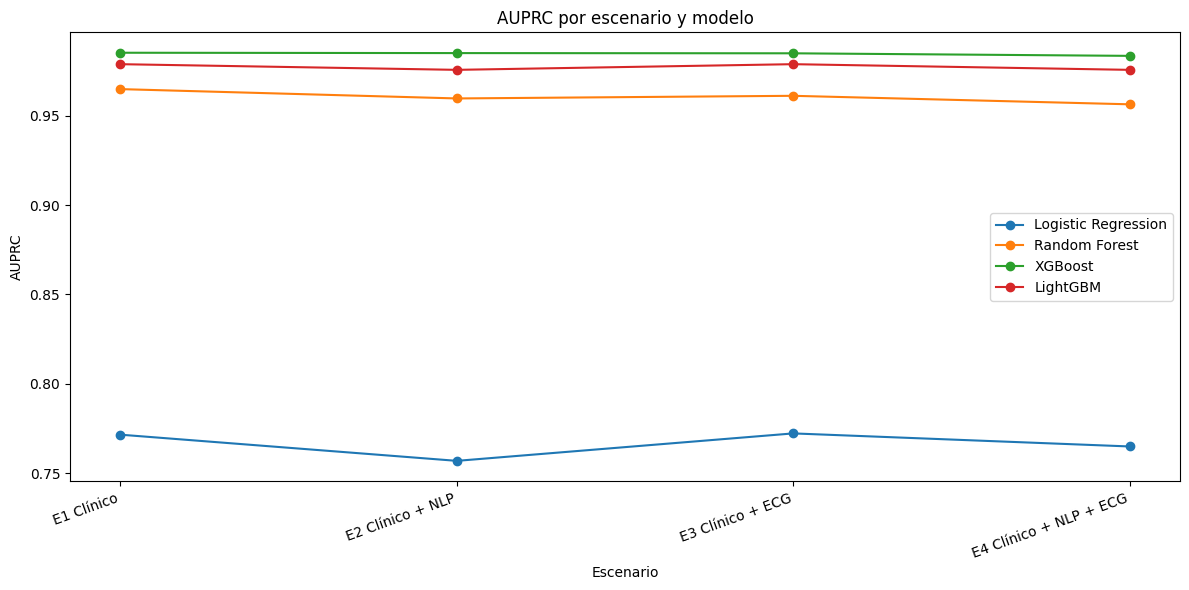

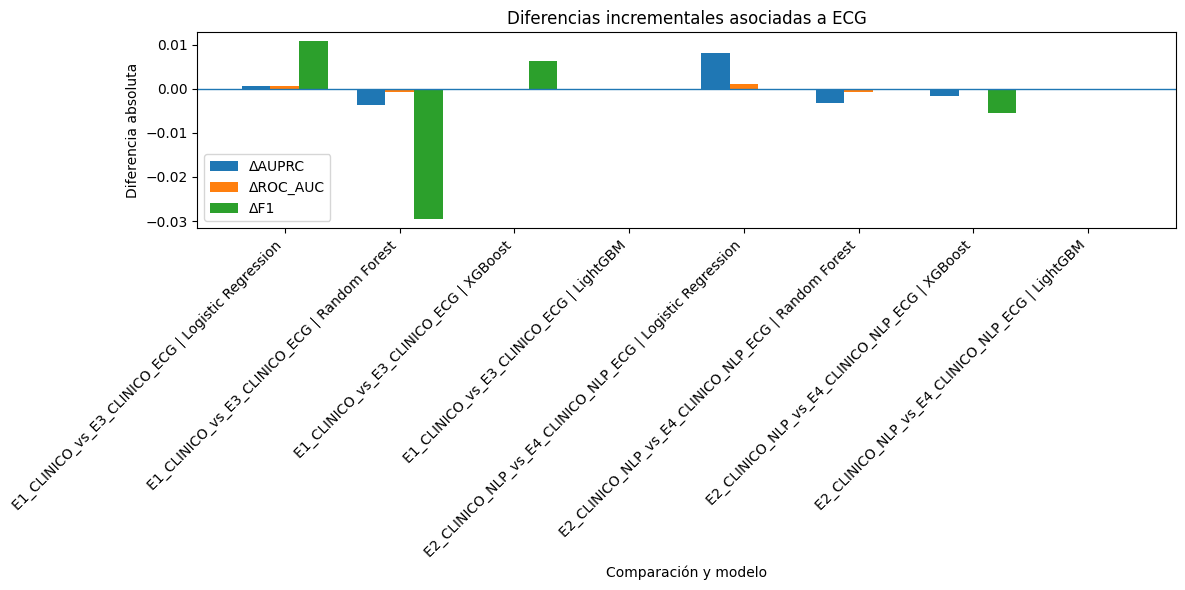

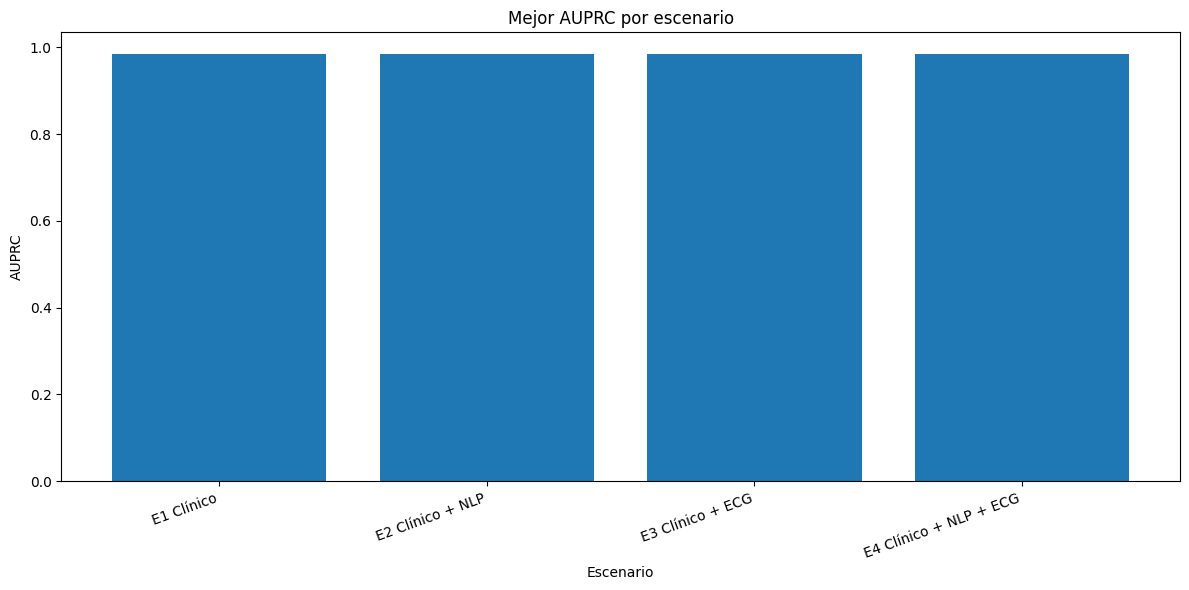

Figuras guardadas:
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\figuras_evaluacion_incremental\metricas_por_escenario_modelo.png
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\figuras_evaluacion_incremental\delta_incremental_ecg.png
e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\figuras_evaluacion_incremental\ranking_auprc_por_escenario.png


In [24]:
# Figura 1: AUPRC por escenario y modelo
plt.figure(figsize=(12, 6))
plot_df = ranking.copy()
for modelo in MODELOS_ESPERADOS:
    tmp = plot_df[plot_df["modelo"].eq(modelo)]
    tmp = tmp.set_index("escenario").reindex(ESCENARIOS_ESPERADOS).reset_index()
    plt.plot(tmp["escenario"].map(scenario_label), tmp["AUPRC"], marker="o", label=modelo)
plt.title("AUPRC por escenario y modelo")
plt.xlabel("Escenario")
plt.ylabel("AUPRC")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_METRICAS, dpi=150)
plt.show()

# Figura 2: delta AUPRC/ROC_AUC/F1 para comparaciones ECG
plt.figure(figsize=(12, 6))
delta_cols = ["delta_AUPRC", "delta_ROC_AUC", "delta_F1"]
delta_plot = aporte_ecg[["comparacion", "modelo"] + delta_cols].copy()
delta_plot["label"] = delta_plot["comparacion"] + " | " + delta_plot["modelo"]
x = np.arange(len(delta_plot))
width = 0.25
for i, col in enumerate(delta_cols):
    plt.bar(x + (i - 1) * width, delta_plot[col], width, label=col.replace("delta_", "Δ"))
plt.axhline(0, linewidth=1)
plt.title("Diferencias incrementales asociadas a ECG")
plt.xlabel("Comparación y modelo")
plt.ylabel("Diferencia absoluta")
plt.xticks(x, delta_plot["label"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DELTA_ECG, dpi=150)
plt.show()

# Figura 3: ranking AUPRC por escenario
plt.figure(figsize=(12, 6))
rank_plot = mejores_por_escenario.sort_values("AUPRC", ascending=False)
plt.bar(rank_plot["escenario"].map(scenario_label), rank_plot["AUPRC"])
plt.title("Mejor AUPRC por escenario")
plt.xlabel("Escenario")
plt.ylabel("AUPRC")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_RANKING, dpi=150)
plt.show()

print("Figuras guardadas:")
print(FIG_METRICAS)
print(FIG_DELTA_ECG)
print(FIG_RANKING)

## 12. Exportación de tablas

In [ ]:
with pd.ExcelWriter(OUT_COMPARACION, engine="xlsxwriter") as writer:
    comparacion_incremental.to_excel(writer, sheet_name="COMPARACION_INCREMENTAL", index=False)
    aporte_ecg.to_excel(writer, sheet_name="APORTE_ECG", index=False)
    if not comparacion_por_subset.empty:
        comparacion_por_subset.to_excel(writer, sheet_name="COMPARACION_SUBSETS", index=False)

with pd.ExcelWriter(OUT_RANKING, engine="xlsxwriter") as writer:
    ranking.to_excel(writer, sheet_name="RANKING_COMPLETO", index=False)
    mejores_por_escenario.to_excel(writer, sheet_name="MEJORES_ESCENARIO", index=False)
    mejor_global.to_excel(writer, sheet_name="MEJOR_GLOBAL", index=False)

print("Archivos exportados:")
print(OUT_COMPARACION)
print(OUT_RANKING)

## 13. Generación de reporte técnico

In [26]:
def fmt(x, nd=4):
    if pd.isna(x):
        return "NA"
    return f"{x:.{nd}f}"

lines = []
lines.append("RESUMEN EVALUACION INCREMENTAL ECG")
lines.append("=" * 70)
lines.append(f"Fecha generacion: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
lines.append("")
lines.append("ENTRADAS")
lines.append("-" * 70)
lines.append(f"Metricas: {PATH_METRICAS}")
lines.append(f"Predicciones: {PATH_PREDICCIONES if PATH_PREDICCIONES.exists() else 'No disponible'}")
lines.append(f"Variables modelado: {PATH_VARIABLES if PATH_VARIABLES.exists() else 'No disponible'}")
lines.append("")
lines.append("ESCENARIOS EVALUADOS")
lines.append("-" * 70)
for e in escenarios_presentes:
    lines.append(f"- {e}")
lines.append("")
lines.append("MODELOS EVALUADOS")
lines.append("-" * 70)
for m in modelos_presentes:
    lines.append(f"- {m}")

lines.append("")
lines.append("MEJOR MODELO POR ESCENARIO")
lines.append("-" * 70)
for _, r in mejores_por_escenario.iterrows():
    lines.append(
        f"{r['escenario']}: {r['modelo']} | AUPRC={fmt(r['AUPRC'])} | ROC_AUC={fmt(r['ROC_AUC'])} | F1={fmt(r['F1'])}"
    )

if not mejor_global.empty:
    r = mejor_global.iloc[0]
    lines.append("")
    lines.append("MEJOR CONFIGURACION GLOBAL")
    lines.append("-" * 70)
    lines.append(
        f"Escenario={r['escenario']} | Modelo={r['modelo']} | AUPRC={fmt(r['AUPRC'])} | ROC_AUC={fmt(r['ROC_AUC'])} | F1={fmt(r['F1'])}"
    )

lines.append("")
lines.append("APORTE INCREMENTAL ECG")
lines.append("-" * 70)
for _, r in aporte_ecg.sort_values(["comparacion", "delta_AUPRC"], ascending=[True, False]).iterrows():
    lines.append(
        f"{r['comparacion']} | {r['modelo']} | "
        f"ΔAUPRC={fmt(r['delta_AUPRC'])} | ΔROC_AUC={fmt(r['delta_ROC_AUC'])} | ΔF1={fmt(r['delta_F1'])} | "
        f"ΔRecall={fmt(r['delta_Recall'])} | ΔPrecision={fmt(r['delta_Precision'])}"
    )

# Síntesis principal: promedio por comparación ECG
lines.append("")
lines.append("SINTESIS PROMEDIO DE COMPARACIONES ECG")
lines.append("-" * 70)
for comp_name, g in aporte_ecg.groupby("comparacion"):
    lines.append(
        f"{comp_name}: "
        f"media ΔAUPRC={fmt(g['delta_AUPRC'].mean())}, "
        f"media ΔROC_AUC={fmt(g['delta_ROC_AUC'].mean())}, "
        f"media ΔF1={fmt(g['delta_F1'].mean())}"
    )

lines.append("")
lines.append("EVALUACION POR SUBCONJUNTOS ESTRUCTURALES")
lines.append("-" * 70)
lines.append(subset_msg)

lines.append("")
lines.append("INTERPRETACION METODOLOGICA")
lines.append("-" * 70)
lines.append("Este notebook compara metricas obtenidas previamente y no reentrena modelos.")
lines.append("La comparacion principal para evaluar aporte ECG corresponde a E1_CLINICO vs E3_CLINICO_ECG.")
lines.append("La comparacion complementaria corresponde a E2_CLINICO_NLP vs E4_CLINICO_NLP_ECG.")
lines.append("Las diferencias positivas en AUPRC, ROC_AUC y F1 son evidencia cuantitativa de mejora incremental bajo la configuracion evaluada.")

OUT_REPORTE.write_text("\n".join(lines), encoding="utf-8")
print("Reporte generado:", OUT_REPORTE)
print("\n".join(lines[:35]))

Reporte generado: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Resumen_Evaluacion_Incremental_TFM.txt
RESUMEN EVALUACION INCREMENTAL ECG
Fecha generacion: 2026-06-23 11:48:11

ENTRADAS
----------------------------------------------------------------------
Metricas: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Metricas_Modelado_TFM.xlsx
Predicciones: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Predicciones_Modelos_TFM.xlsx
Variables modelado: e:\Capacitacion 2025\Magister en Inteligencia Artificial\99 Trabajo Fin de Estudios TFE\GitHub\tfm-ecg-riesgo-cardiometabolico\notebooks\Variables_Modelado_TFM.xlsx

ESCENARIOS EVALUADOS
----------------------------------------------------------------------
- E1_CLINICO
- E2_C

## 14. Consideraciones metodológicas finales

La evaluación incremental se interpreta dentro del marco experimental del TFM. Una diferencia positiva entre escenarios indica mejora observada bajo los datos, modelos y particiones utilizados. Esta evidencia no equivale a validación clínica externa.

El análisis principal se centra en `E1_CLINICO → E3_CLINICO_ECG`. El análisis complementario `E2_CLINICO_NLP → E4_CLINICO_NLP_ECG` permite verificar si la modalidad ECG mantiene aporte cuando el modelo ya incorpora antecedentes procesados mediante NLP.